# Retrieval face-off bar chart

One bar per pointwise judge on the matched face-off subset: the PaperFinder retrieval
judges at **k=1** beside the **web-search** judge, so the strong retriever is read against
the ordinary ones on identical instances.

Numbers come straight from `subset_scores.json`, written by
`novelty_eval.retrieval_faceoff.subset_reports`. Nothing is recomputed here — regenerate
that file with `./scripts/eval/run_retrieval_faceoff.sh recompute ROOT` if it is stale.

Everything the chart says — which judges appear, what they are called, the metric, the
axis titles — lives in the one config cell below.

In [33]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir() and (p / "output").is_dir()
)
sys.path.insert(0, str(ROOT / "src"))

from novelty_eval.analysis.artifacts import _extract_raw_outcomes_for_dir
from novelty_eval.analysis.stats_one_pass import (
    _POINTWISE_METRIC_KEYS,
    _all_pointwise_metrics,
    _run_bootstrap_multi,
)

# Newest face-off run holding scores. Pin a directory here to freeze the figure
# against a specific run.
RUN = sorted((ROOT / "output/retrieval_faceoff").glob("*/subset_scores.json"))[-1].parent

SCORES = json.loads((RUN / "subset_scores.json").read_text())
print(f"{RUN.relative_to(ROOT)} -> {len(SCORES)} scored runs")

output/retrieval_faceoff/20260904_114948 -> 25 scored runs


In [34]:
# ---- everything the chart says, in one place ---------------------------------

# Which metric to plot, and what to call it on the axis. Any key under "metrics"
# in subset_scores.json works: accuracy, f1_macro, f1_pos, f1_neg, ...
METRIC = "f1_macro"
# Bars are horizontal, so the metric is the x-axis and the judges the y-axis.
# These are named for what they label, not for which axis they land on.
METRIC_LABEL = "F1 (macro)"
# Empty by default: the tick labels already name the judges, so an axis title here
# only adds weight to the left margin. Set it to "Judge" to bring it back.
JUDGE_LABEL = "Backbone Model"
# Heads the legend box, naming what the two colours encode. "" drops the title.
LEGEND_TITLE = "Retrieval Type"

# config name in subset_scores.json -> group key. A run whose config is not listed
# is dropped, which is what restricts this to the k=1 and web-search judges.
CONFIGS = {
    "pointwise-vanilla-ai_retrieval_mec_k_1": "paperfinder",
    "web_search_self_judge": "web_search",
}

# Group key -> legend label and bar colour. Two hues, because the comparison the
# figure makes is retrieval-source, not per-judge identity: the judges themselves
# are already named down the axis, so a hue each would encode nothing new.
#
# Both are cost_efficiency.ipynb's swatches. #757bc4 is the colour that notebook
# gives k=1 runs, which is what these judges are; the wine is its emphasis hue and
# carries the one bar the figure is about. Checked with the palette validator:
# CVD dE 19.5, normal dE 24.1, both at least 3:1 on white.
GROUPS = {
    "paperfinder": ("Standard", "#757bc4"),
    "web_search": ("Powerful agentic RAG", "#8f204f"),
}

# The group the figure is about: its row gets a tint behind it and its value is set
# in ink rather than muted. None for no emphasis.
HIGHLIGHT = "web_search"

# Model id -> the name on the axis. A model missing from here is dropped, so this
# doubles as the judge selection.
JUDGES = {
    "claude-opus-4-6": "Opus 4.6",
    "claude-opus-4-5": "Opus 4.5",
    "claude-sonnet-4-5": "Sonnet 4.5",
    "gpt-5.4": "GPT-5.4",
    "gpt-5.2": "GPT-5.2",
    "gpt-5.1": "GPT-5.1",
    "gpt-5.6-sol": "GPT-5.6-Sol",
}

# True sorts bars by the metric; False keeps the JUDGES order above.
SORT_BY_VALUE = True

# 95% bootstrap confidence interval over test instances, drawn as an error bar.
# The interval moved by <0.001 between 2000 and 10000 resamples in the sibling
# cost_efficiency notebook; 10000 takes a couple of seconds for seven runs.
SHOW_ERROR_BARS = True
N_RESAMPLES = 10000
SEED = 42
# What the interval is called in the legend. "" drops that entry but keeps the bars.
CI_LABEL = "95% bootstrap CI"

# Ink, muted ink and grid: text never wears the series colour, the bar beside it
# already carries that. White surface, so the figure drops onto a white page.
# BAND is the highlight tint — light enough that the bar on it still reads.
INK, MUTED, GRID, SURFACE, BAND = "#23233c", "#5c5a70", "#e7e0d6", "#ffffff", "#f7f3ef"

FIGSIZE = (6.0, 3.2)
OUT = ROOT / "output/figures/retrieval-faceoff/retrieval_faceoff_bars.pdf"

In [35]:
def bootstrap_ci(run_dir, excluded, metrics):
    """95% CI for METRIC on one run, resampling the instances it was scored on.

    subset_scores.json carries the metric but not the per-instance outcomes, so the
    interval is computed from the run's own scores.json, filtered to the same subset
    (`excluded` is the exclude set subset_reports used). The assert below is the check
    that those two really are the same run: if the point estimate off scores.json
    disagrees with the plotted number, the CI belongs to some other run and the bar is
    wrong. Resampling is paired across (pred, target), so an instance is drawn whole.
    """
    d = Path(run_dir)
    outcomes = _extract_raw_outcomes_for_dir(d if d.is_absolute() else ROOT / d,
                                             "pointwise", "", None)
    pred, target = outcomes["_pointwise_pred"], outcomes["_pointwise_target"]
    pids = sorted(p for p in pred if p not in excluded)   # sorted: a stable instance order
    data = (np.array([pred[p] for p in pids]), np.array([target[p] for p in pids]))

    point = dict(zip(_POINTWISE_METRIC_KEYS, _all_pointwise_metrics(*data)))
    assert abs(point[METRIC] - metrics[METRIC]) < 5e-4, \
        f"{run_dir}: scores.json says {point[METRIC]:.4f}, subset_scores.json {metrics[METRIC]:.4f}"

    boot = _run_bootstrap_multi(data, _all_pointwise_metrics, _POINTWISE_METRIC_KEYS,
                                n_resamples=N_RESAMPLES, random_state=SEED,
                                label=str(run_dir), _logger=None)[METRIC]
    return boot["ci_low"], boot["ci_high"], len(pids)


def build_row(r):
    """One tidy row per drawn bar, CI included."""
    lo, hi, n = (bootstrap_ci(r["artifact_dir"], set(r["metrics"]["excluded"]), r["metrics"])
                 if SHOW_ERROR_BARS else (np.nan, np.nan, r["metrics"]["support"]))
    return {
        "group": CONFIGS[r["config"]],
        "model": r["model"],
        "label": JUDGES[r["model"]],
        METRIC: r["metrics"][METRIC],
        "ci_low": lo,
        "ci_high": hi,
        "support": n,
        "run_dir": r["artifact_dir"],
    }


df = pd.DataFrame([
    build_row(r) for r in SCORES
    if r["mode"] == "pointwise" and r["config"] in CONFIGS and r["model"] in JUDGES
])

if SORT_BY_VALUE:
    df = df.sort_values(METRIC, ascending=False, ignore_index=True)
else:
    order = list(JUDGES)
    df = df.sort_values("model", key=lambda s: s.map(order.index), ignore_index=True)

assert not df.empty, "no rows matched CONFIGS/JUDGES — check the names against subset_scores.json"
assert df["model"].is_unique, f"a model appears under two configs: {df['model'].tolist()}"
print(f"{len(df)} bars, support {sorted(df['support'].unique())}")
df[["group", "label", METRIC, "ci_low", "ci_high", "support"]]

7 bars, support [np.int64(308)]


,group,label,f1_macro,ci_low,ci_high,support
0,paperfinder,Opus 4.6,0.889044,0.849925,0.920999,308
1,web_search,GPT-5.6-Sol,0.777836,0.727139,0.822755,308
2,paperfinder,Opus 4.5,0.763495,0.713222,0.808865,308
3,paperfinder,GPT-5.4,0.736058,0.682147,0.785104,308
4,paperfinder,GPT-5.1,0.729879,0.678541,0.778089,308
5,paperfinder,GPT-5.2,0.697770,0.642190,0.747617,308
6,paperfinder,Sonnet 4.5,0.665028,0.611844,0.718105,308


wrote output/figures/retrieval-faceoff/retrieval_faceoff_bars.pdf (+ .png)


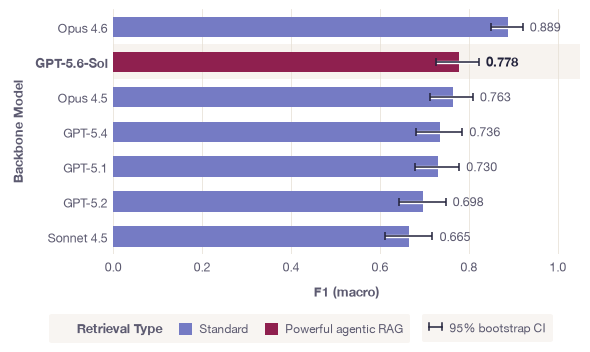

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "pdf.fonttype": 42,  # embed TrueType outlines; most venues reject Type 3
})

fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

pos = np.arange(len(df))
hot = (df["group"] == HIGHLIGHT).to_numpy()   # the rows the figure is about

# A tint across the highlighted row, full width, so the eye lands on it before it
# starts reading values. Behind everything, and light enough not to tint the bar.
for y in pos[hot]:
    ax.axhspan(y - 0.5, y + 0.5, color=BAND, zorder=0, lw=0)

ax.barh(pos, df[METRIC], height=0.58,
        color=[GROUPS[g][1] for g in df["group"]], zorder=2)

if SHOW_ERROR_BARS:
    # The interval is asymmetric, so each arm is given its own length. Drawn twice:
    # a thicker surface-coloured pass underneath leaves a halo, so the bar reads
    # against the dark fill it crosses and against the white page beyond it.
    err = np.vstack([df[METRIC] - df["ci_low"], df["ci_high"] - df[METRIC]])
    # Caps on the ink pass only: a capped halo puts a white block inside the bar,
    # which reads as a notch in the fill rather than as an outline.
    for lw, colour, cap, z in ((2.4, SURFACE, 0, 3), (1.1, INK, 2.6, 4)):
        ax.errorbar(df[METRIC], pos, xerr=err, fmt="none", ecolor=colour,
                    elinewidth=lw, capsize=cap, capthick=lw, zorder=z)

# The number on every bar: colour is then never the only encoding, and a paper
# reader gets the exact value without going back to the table. Placed past the
# upper arm so it never sits on the interval; the highlighted row is set in ink.
label_x = df["ci_high"] if SHOW_ERROR_BARS else df[METRIC]
for y, v, x, is_hot in zip(pos, df[METRIC], label_x, hot):
    ax.text(x + 0.016, y, f"{v:.3f}", va="center", fontsize=9.0, zorder=5,
            color=INK if is_hot else MUTED,
            fontweight="bold" if is_hot else "normal")

ax.set_yticks(pos, df["label"], fontsize=9.4)
for tick, is_hot in zip(ax.get_yticklabels(), hot):
    tick.set(color=INK if is_hot else MUTED,
             fontweight="bold" if is_hot else "normal")
# Inverted, so the first row of df is the top bar, and tight to the bars so the
# highlight band does not trail off into empty space.
ax.set_ylim(len(df) - 0.5, -0.5)
ax.set_xlim(0, label_x.max() * 1.14)   # bars start at zero, room for the labels
ax.set_xlabel(METRIC_LABEL, fontsize=9.4, color=MUTED, labelpad=7, fontweight="bold")
ax.set_ylabel(JUDGE_LABEL, fontsize=9.4, color=MUTED, labelpad=7, fontweight="bold")

# Vertical rules only, and recessive: they are a ruler under the bars, not content.
ax.grid(True, axis="x", color=GRID, lw=0.55)
ax.set_axisbelow(True)
ax.tick_params(labelsize=9.0, colors=MUTED, length=0, pad=4)
for s in ax.spines.values():
    s.set_visible(False)


class _TextOnly(HandlerBase):
    """A legend entry that is its label and nothing else — no swatch drawn.

    matplotlib puts a legend title on its own line above the entries, which costs a
    whole row of height. Running the title through as a swatch-less first entry keeps
    the key one line tall.
    """

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        # An empty list trips HandlerBase, which indexes artists[0]; an invisible
        # zero-size patch satisfies it and draws nothing.
        blank = Rectangle((0, 0), 0, 0, visible=False)
        blank.set_transform(trans)
        return [blank]


class _ErrorBarKey(HandlerBase):
    """Draws the interval mark itself: a rule with a cap at each end.

    Rather than a proxy that merely resembles it, so the key cannot drift from the
    bars if the error-bar styling above changes.
    """

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        mid, cap = height / 2, height * 0.3
        arts = [Line2D([0, width], [mid, mid], color=INK, lw=1.1),
                *(Line2D([x, x], [mid - cap, mid + cap], color=INK, lw=1.1)
                  for x in (0, width))]
        for a in arts:
            a.set_transform(trans)
        return arts


# Below the axis, not inside it: with the bars sorted there is no empty corner left,
# and a legend placed in one would sit on a value label.
LEGEND_Y = -0.22      # separation from the axis title above; lower it for more air
LEGEND_GAP = 0.025    # between the two panels, in axes widths


def panel(handles, labels, handler_map, loc, x):
    """One key panel: a soft tinted box with no outline, anchored at x."""
    leg = ax.legend(handles, labels, loc=loc, bbox_to_anchor=(x, LEGEND_Y),
                    ncol=len(handles), handler_map=handler_map,
                    frameon=True, fontsize=8.6, labelcolor=MUTED,
                    handlelength=1.1, handleheight=1.1, columnspacing=1.4,
                    borderpad=0.6, handletextpad=0.6)
    # Grouped by ground rather than by a rule, so nothing on the page competes with
    # the bars for a reader's attention.
    leg.get_frame().set(facecolor=BAND, edgecolor="none")
    return leg


def axes_width(artist):
    """Width of a drawn artist, in axes coordinates."""
    bb = artist.get_window_extent()
    x0, x1 = ax.transAxes.inverted().transform([(bb.x0, 0), (bb.x1, 0)])[:, 0]
    return x1 - x0


drawn = list(dict.fromkeys(df["group"]))   # legend order follows the bars
handles = [Patch(facecolor=GROUPS[g][1]) for g in drawn]
labels = [GROUPS[g][0] for g in drawn]
handler_map = {}
if LEGEND_TITLE:
    spacer = Patch(visible=False)
    handles.insert(0, spacer)
    labels.insert(0, LEGEND_TITLE)
    handler_map[spacer] = _TextOnly()

fig.tight_layout()

# Centre the keys on the axes *together with its labels*, not on the plot box alone:
# the tick labels and the y-axis title hang off to the left, so a key centred on the
# plot box sits right of centre once the figure is cropped tight on save. Measured
# before the keys exist, so it is not measuring itself.
fig.canvas.draw()
span = ax.get_tightbbox(fig.canvas.get_renderer())
x0, x1 = ax.transAxes.inverted().transform([(span.x0, 0), (span.x1, 0)])[:, 0]
centre = (x0 + x1) / 2

# The interval keys a different dimension from the colours -- uncertainty on every
# bar, not which retrieval a bar used -- so it gets a box of its own rather than
# riding under the "retrieval type" title as if it were a third type.
type_legend = panel(handles, labels, handler_map, "upper center", centre)
if LEGEND_TITLE:
    type_legend.get_texts()[0].set(color=MUTED, fontweight="bold", fontsize=9.0)

if SHOW_ERROR_BARS and CI_LABEL:
    ax.add_artist(type_legend)      # a second ax.legend() would replace the first
    ci_key = Patch(visible=False)
    ci_legend = panel([ci_key], [CI_LABEL], {ci_key: _ErrorBarKey()}, "upper left", centre)

    # Lay the pair out as one block centred on `centre`: anchor the wide panel by its
    # right edge and the narrow one by its left, both offset from the block's start.
    fig.canvas.draw()
    w_type, w_ci = axes_width(type_legend), axes_width(ci_legend)
    left = centre - (w_type + LEGEND_GAP + w_ci) / 2
    type_legend.set_loc("upper left")
    type_legend.set_bbox_to_anchor((left, LEGEND_Y), transform=ax.transAxes)
    ci_legend.set_bbox_to_anchor((left + w_type + LEGEND_GAP, LEGEND_Y),
                                 transform=ax.transAxes)

OUT.parent.mkdir(parents=True, exist_ok=True)
for path in (OUT, OUT.with_suffix(".png")):
    fig.savefig(path, bbox_inches="tight", dpi=200, facecolor=SURFACE)
print(f"wrote {OUT.relative_to(ROOT)} (+ .png)")
